# 南华工业品原始数据 Bry-Boschan 拐点识别

读取当前文件夹中的 `南华工业品.csv`，不做滤波、不做去噪，直接对原始月度数据应用 Bry-Boschan-like 拐点识别。

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA_FILE = ROOT / "南华工业品.csv"
OUT = ROOT / "nanhua_industrial_bb_output"
OUT.mkdir(exist_ok=True)

# BB 参数：沿用前面原始数据版本的默认口径。
BB_WINDOW = 5
MIN_PHASE = 5
MIN_CYCLE = 15

## 1. 读取 CSV 并提取原始月度序列

In [24]:
def read_csv_with_fallback(path: Path) -> pd.DataFrame:
    raw_bytes = path.read_bytes()
    encodings = ["utf-8-sig", "utf-8", "gb18030", "gbk", "cp936"]

    text = None
    used_encoding = None
    for encoding in encodings:
        try:
            text = raw_bytes.decode(encoding)
            used_encoding = encoding
            break
        except UnicodeDecodeError:
            continue

    if text is None:
        text = raw_bytes.decode("gb18030", errors="replace")
        used_encoding = "gb18030_replace"

    rows = []
    for line in text.splitlines():
        line = line.strip().lstrip("\ufeff")
        if not line:
            continue
        if "," in line:
            left, right = line.split(",", 1)
        else:
            left, right = line, ""
        rows.append({"date": left.strip(), "value": right.strip()})

    df = pd.DataFrame(rows, columns=["date", "value"])
    df.attrs["encoding"] = used_encoding
    return df


def read_nanhua_series(path: Path) -> tuple[pd.Series, dict]:
    raw = read_csv_with_fallback(path)
    print(f"读取编码：{raw.attrs.get('encoding')}")

    metadata = {}
    for _, row in raw.iloc[:5].iterrows():
        key = str(row["date"]).strip()
        value = "" if pd.isna(row["value"]) else str(row["value"]).strip()
        metadata[key] = value

    data = raw.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data["value"] = pd.to_numeric(data["value"], errors="coerce")
    data = data.dropna(subset=["date", "value"])

    month_end = pd.DatetimeIndex(data["date"]).to_period("M").to_timestamp("M")
    series = pd.Series(data["value"].to_numpy(), index=month_end, name=metadata.get("指标名称", "南华工业品"))
    series = series.sort_index().groupby(level=0).last()
    series = series.reindex(pd.date_range(series.index.min(), series.index.max(), freq="ME"))
    series = series.interpolate(limit=2).dropna()
    return series, metadata


series, metadata = read_nanhua_series(DATA_FILE)

display(pd.DataFrame([{
    "file": DATA_FILE.name,
    "name": series.name,
    "frequency": metadata.get("频率", ""),
    "unit": metadata.get("单位", ""),
    "id": metadata.get("指标ID", ""),
    "source": metadata.get("来源", ""),
    "start": series.index.min(),
    "end": series.index.max(),
    "nobs": len(series),
    "last_value": series.iloc[-1],
}]))
display(series.to_frame("value").head(12))
display(series.to_frame("value").tail(12))

读取编码：gb18030


C:\Users\16492\AppData\Local\Temp\ipykernel_42860\3112498249.py:46: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["date"] = pd.to_datetime(data["date"], errors="coerce")


,file,name,frequency,unit,id,source,start,end,nobs,last_value
0,南华工业品.csv,中国:建信高金宏观因子:增长因子,月,,M6641380,建信基金,2008-12-31,2026-05-31,210,3.187202


,value
2008-12-31,8.304135
2009-01-31,8.794387
2009-02-28,9.356454
2009-03-31,10.000363
2009-04-30,10.723574
2009-05-31,11.499607
2009-06-30,12.363628
2009-07-31,13.333314
2009-08-31,14.323846
2009-09-30,15.225280


,value
2025-06-30,4.932203
2025-07-31,4.870343
2025-08-31,4.551732
2025-09-30,4.563419
2025-10-31,4.602699
2025-11-30,3.972118
2025-12-31,3.550049
2026-01-31,3.627906
2026-02-28,3.689215
2026-03-31,3.777512


## 2. Bry-Boschan-like 拐点函数

In [25]:
def local_turns(y: pd.Series, window: int = 5) -> pd.DataFrame:
    y = y.dropna()
    rows = []
    for i in range(window, len(y) - window):
        block = y.iloc[i - window : i + window + 1]
        value = y.iloc[i]
        if value == block.max() and value > y.iloc[i - 1] and value > y.iloc[i + 1]:
            rows.append({"date": y.index[i], "type": "peak", "value": value})
        if value == block.min() and value < y.iloc[i - 1] and value < y.iloc[i + 1]:
            rows.append({"date": y.index[i], "type": "trough", "value": value})
    return pd.DataFrame(rows, columns=["date", "type", "value"]).sort_values("date").reset_index(drop=True)


def alternate(turns: pd.DataFrame) -> pd.DataFrame:
    if turns.empty:
        return turns.copy()
    kept = []
    for row in turns.to_dict("records"):
        if not kept or row["type"] != kept[-1]["type"]:
            kept.append(row)
            continue
        better_peak = row["type"] == "peak" and row["value"] > kept[-1]["value"]
        better_trough = row["type"] == "trough" and row["value"] < kept[-1]["value"]
        if better_peak or better_trough:
            kept[-1] = row
    return pd.DataFrame(kept, columns=turns.columns)


def enforce_lengths(turns: pd.DataFrame, min_phase: int = 5, min_cycle: int = 15) -> pd.DataFrame:
    turns = alternate(turns)
    changed = True
    while changed and len(turns) > 2:
        changed = False
        turns = turns.reset_index(drop=True)

        for i in range(len(turns) - 1):
            months = (turns.loc[i + 1, "date"].to_period("M") - turns.loc[i, "date"].to_period("M")).n
            if months < min_phase:
                amp_left = abs(turns.loc[i, "value"] - turns["value"].median())
                amp_right = abs(turns.loc[i + 1, "value"] - turns["value"].median())
                turns = turns.drop(i if amp_left < amp_right else i + 1)
                changed = True
                break
        if changed:
            turns = alternate(turns)
            continue

        for i in range(len(turns) - 2):
            months = (turns.loc[i + 2, "date"].to_period("M") - turns.loc[i, "date"].to_period("M")).n
            if turns.loc[i, "type"] == turns.loc[i + 2, "type"] and months < min_cycle:
                if turns.loc[i, "type"] == "peak":
                    drop_i = i if turns.loc[i, "value"] < turns.loc[i + 2, "value"] else i + 2
                else:
                    drop_i = i if turns.loc[i, "value"] > turns.loc[i + 2, "value"] else i + 2
                turns = turns.drop(drop_i)
                changed = True
                break
        turns = alternate(turns)
    return turns.reset_index(drop=True)


def bry_boschan_like(y: pd.Series, window: int = BB_WINDOW, min_phase: int = MIN_PHASE, min_cycle: int = MIN_CYCLE) -> pd.DataFrame:
    turns = enforce_lengths(local_turns(y, window=window), min_phase=min_phase, min_cycle=min_cycle)
    if turns.empty:
        turns["turn"] = []
        return turns
    turns["turn"] = turns["type"].map({"peak": "高点", "trough": "低点"})
    return turns


def phase_by_turns(index: pd.DatetimeIndex, turns: pd.DataFrame) -> pd.Series:
    phase = pd.Series(index=index, dtype="object")
    if turns.empty or len(index) == 0:
        return phase
    turns = turns.sort_values("date").reset_index(drop=True)

    first = turns.loc[0]
    before_first = "上行" if first["type"] == "peak" else "下行"
    phase.loc[index < first["date"]] = before_first

    for i, row in turns.iterrows():
        start = row["date"]
        end = turns.loc[i + 1, "date"] if i < len(turns) - 1 else index[-1] + pd.offsets.MonthEnd(1)
        after_turn = "下行" if row["type"] == "peak" else "上行"
        phase.loc[(index >= start) & (index < end)] = after_turn
    return phase

## 3. 对原始数据直接跑 BB

In [26]:
turning_points = bry_boschan_like(series)
turning_points.insert(0, "name", series.name)

states = pd.DataFrame(index=series.index)
states["value"] = series
states["phase"] = phase_by_turns(series.index, turning_points)
states["direction"] = states["phase"].map({"上行": 1, "下行": -1})

latest = states.dropna(subset=["phase"]).iloc[-1]
latest_summary = pd.DataFrame([{
    "latest_state_date": latest.name,
    "latest_value": latest["value"],
    "latest_phase": latest["phase"],
    "latest_direction": latest["direction"],
    "turns": len(turning_points),
    "window": BB_WINDOW,
    "min_phase": MIN_PHASE,
    "min_cycle": MIN_CYCLE,
}])

display(latest_summary)
display(turning_points)
display(states.tail(24))

,latest_state_date,latest_value,latest_phase,latest_direction,turns,window,min_phase,min_cycle
0,2026-05-31,3.187202,上行,1,12,5,5,15


,name,date,type,value,turn
0,中国:建信高金宏观因子:增长因子,2010-01-31,peak,16.670516,高点
1,中国:建信高金宏观因子:增长因子,2010-12-31,trough,13.029287,低点
2,中国:建信高金宏观因子:增长因子,2011-06-30,peak,14.809606,高点
3,中国:建信高金宏观因子:增长因子,2013-03-31,trough,8.727312,低点
4,中国:建信高金宏观因子:增长因子,2014-02-28,peak,10.081480,高点
5,中国:建信高金宏观因子:增长因子,2015-10-31,trough,5.170399,低点
6,中国:建信高金宏观因子:增长因子,2017-03-31,peak,7.112789,高点
7,中国:建信高金宏观因子:增长因子,2020-03-31,trough,3.780264,低点
8,中国:建信高金宏观因子:增长因子,2021-03-31,peak,8.838604,高点
9,中国:建信高金宏观因子:增长因子,2022-05-31,trough,3.634826,低点


,value,phase,direction
2024-06-30,4.844489,下行,-1
2024-07-31,4.869021,下行,-1
2024-08-31,4.868894,下行,-1
2024-09-30,5.259825,下行,-1
2024-10-31,5.059311,下行,-1
2024-11-30,5.023260,下行,-1
2024-12-31,4.955188,下行,-1
2025-01-31,4.772215,上行,1
2025-02-28,4.800669,上行,1
2025-03-31,5.038400,上行,1


## 4. 汇总阶段区间并导出

In [27]:
def state_blocks(states: pd.DataFrame) -> pd.DataFrame:
    x = states.dropna(subset=["phase"]).copy()
    block_id = x["phase"].ne(x["phase"].shift()).cumsum()
    rows = []
    for _, block in x.groupby(block_id):
        rows.append({
            "start": block.index.min(),
            "end": block.index.max(),
            "months": len(block),
            "phase": block["phase"].iloc[0],
            "direction": block["direction"].iloc[0],
            "start_value": block["value"].iloc[0],
            "end_value": block["value"].iloc[-1],
        })
    return pd.DataFrame(rows)


state_summary = state_blocks(states)

series.rename("value").to_csv(OUT / "nanhua_industrial_raw_series.csv", encoding="utf-8-sig")
turning_points.to_csv(OUT / "nanhua_industrial_bb_turning_points.csv", index=False, encoding="utf-8-sig")
states.rename_axis("date").reset_index().to_csv(OUT / "nanhua_industrial_bb_states_by_month.csv", index=False, encoding="utf-8-sig")
state_summary.to_csv(OUT / "nanhua_industrial_bb_state_blocks.csv", index=False, encoding="utf-8-sig")
latest_summary.to_csv(OUT / "nanhua_industrial_bb_latest_state.csv", index=False, encoding="utf-8-sig")

display(state_summary)
print(f"已导出到：{OUT}")

,start,end,months,phase,direction,start_value,end_value
0,2008-12-31,2009-12-31,13,上行,1,8.304135,16.615501
1,2010-01-31,2010-11-30,11,下行,-1,16.670516,13.071749
2,2010-12-31,2011-05-31,6,上行,1,13.029287,14.776938
3,2011-06-30,2013-02-28,21,下行,-1,14.809606,8.872463
4,2013-03-31,2014-01-31,11,上行,1,8.727312,9.296489
5,2014-02-28,2015-09-30,20,下行,-1,10.081480,5.309029
6,2015-10-31,2017-02-28,17,上行,1,5.170399,6.910810
7,2017-03-31,2020-02-29,36,下行,-1,7.112789,4.145645
8,2020-03-31,2021-02-28,12,上行,1,3.780264,8.020882
9,2021-03-31,2022-04-30,14,下行,-1,8.838604,4.332404


已导出到：c:\Users\16492\Desktop\实习内容\数据处理\data\nanhua_industrial_bb_output


## 5. 与给定上行/下行区间对比准确度

In [28]:
TARGET_REGIMES = [
    ("2005-01-31", "2008-04-30", 1),
    ("2008-05-31", "2009-02-28", -1),
    ("2009-03-31", "2010-02-28", 1),
    ("2010-03-31", "2012-08-31", -1),
    ("2012-09-30", "2013-08-31", 1),
    ("2013-09-30", "2016-02-29", -1),
    ("2016-03-31", "2017-06-30", 1),
    ("2017-07-31", "2019-08-31", -1),
    ("2019-09-30", "2019-12-31", 1),
    ("2020-01-31", "2020-03-31", -1),
    ("2020-04-30", "2020-11-30", 1),
]


def build_target(regimes, index: pd.DatetimeIndex) -> pd.Series:
    target = pd.Series(index=index, dtype="float64", name="target_direction")
    for start_text, end_text, direction in regimes:
        start = pd.Timestamp(start_text)
        end = pd.Timestamp(end_text)
        target.loc[(target.index >= start) & (target.index <= end)] = direction
    return target.dropna().astype(int)


target_direction = build_target(TARGET_REGIMES, states.index)
comparison = pd.concat(
    [
        states["value"],
        states["phase"],
        states["direction"].rename("bb_direction"),
        target_direction,
    ],
    axis=1,
    join="inner",
).dropna(subset=["bb_direction", "target_direction"])
comparison["bb_direction"] = comparison["bb_direction"].astype(int)
comparison["match"] = comparison["bb_direction"].eq(comparison["target_direction"])
comparison["bb_label"] = comparison["bb_direction"].map({1: "上行", -1: "下行"})
comparison["target_label"] = comparison["target_direction"].map({1: "上行", -1: "下行"})

accuracy = comparison["match"].mean()
up = comparison[comparison["target_direction"].eq(1)]
down = comparison[comparison["target_direction"].eq(-1)]
up_accuracy = up["match"].mean() if len(up) else np.nan
down_accuracy = down["match"].mean() if len(down) else np.nan
balanced_accuracy = np.nanmean([up_accuracy, down_accuracy])

target_switches = comparison.index[comparison["target_direction"].ne(comparison["target_direction"].shift())][1:]
bb_switches = comparison.index[comparison["bb_direction"].ne(comparison["bb_direction"].shift())][1:]

accuracy_summary = pd.DataFrame([{
    "start": comparison.index.min(),
    "end": comparison.index.max(),
    "months": len(comparison),
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "up_accuracy": up_accuracy,
    "down_accuracy": down_accuracy,
    "target_up_months": len(up),
    "target_down_months": len(down),
    "bb_switches": len(bb_switches),
    "target_switches": len(target_switches),
    "switch_count_gap": abs(len(bb_switches) - len(target_switches)),
}])

display(accuracy_summary)
display(comparison[~comparison["match"]].head(30))
display(comparison.tail(24))

accuracy_summary.to_csv(OUT / "nanhua_industrial_bb_accuracy_summary.csv", index=False, encoding="utf-8-sig")
comparison.rename_axis("date").reset_index().to_csv(OUT / "nanhua_industrial_bb_target_comparison.csv", index=False, encoding="utf-8-sig")

,start,end,months,accuracy,balanced_accuracy,up_accuracy,down_accuracy,target_up_months,target_down_months,bb_switches,target_switches,switch_count_gap
0,2008-12-31,2020-11-30,144,0.75,0.737458,0.692308,0.782609,52,92,8,9,1


,value,phase,bb_direction,target_direction,match,bb_label,target_label
2008-12-31,8.304135,上行,1,-1,False,上行,下行
2009-01-31,8.794387,上行,1,-1,False,上行,下行
2009-02-28,9.356454,上行,1,-1,False,上行,下行
2010-01-31,16.670516,下行,-1,1,False,下行,上行
2010-02-28,16.566261,下行,-1,1,False,下行,上行
2010-12-31,13.029287,上行,1,-1,False,上行,下行
2011-01-31,13.208621,上行,1,-1,False,上行,下行
2011-02-28,13.612025,上行,1,-1,False,上行,下行
2011-03-31,14.095613,上行,1,-1,False,上行,下行
2011-04-30,14.516444,上行,1,-1,False,上行,下行


,value,phase,bb_direction,target_direction,match,bb_label,target_label
2018-12-31,5.386439,下行,-1,-1,True,下行,下行
2019-01-31,5.413254,下行,-1,-1,True,下行,下行
2019-02-28,5.437804,下行,-1,-1,True,下行,下行
2019-03-31,5.773773,下行,-1,-1,True,下行,下行
2019-04-30,5.251213,下行,-1,-1,True,下行,下行
2019-05-31,5.274119,下行,-1,-1,True,下行,下行
2019-06-30,5.555262,下行,-1,-1,True,下行,下行
2019-07-31,5.402474,下行,-1,-1,True,下行,下行
2019-08-31,5.187251,下行,-1,-1,True,下行,下行
2019-09-30,5.370091,下行,-1,1,False,下行,上行


## 6. 画图对比 BB 结论和目标结论

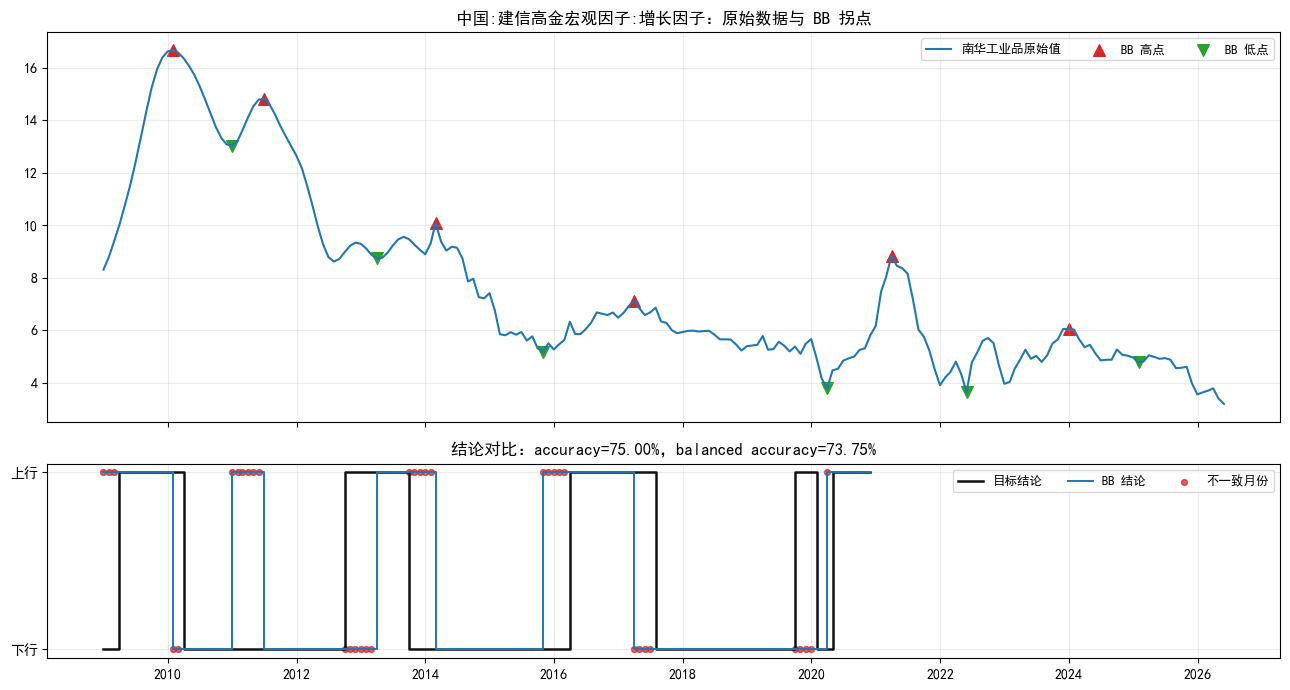

对比图已导出：c:\Users\16492\Desktop\实习内容\数据处理\data\nanhua_industrial_bb_output\nanhua_industrial_bb_vs_target.png


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

peaks = turning_points[turning_points["type"].eq("peak")]
troughs = turning_points[turning_points["type"].eq("trough")]

ax = axes[0]
ax.plot(series.index, series.values, color="#1f77b4", linewidth=1.5, label="南华工业品原始值")
ax.scatter(peaks["date"], peaks["value"], color="#d62728", marker="^", s=70, label="BB 高点")
ax.scatter(troughs["date"], troughs["value"], color="#2ca02c", marker="v", s=70, label="BB 低点")
ax.set_title(f"{series.name}：原始数据与 BB 拐点")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

ax = axes[1]
ax.step(comparison.index, comparison["target_direction"], where="post", color="#111111", linewidth=1.8, label="目标结论")
ax.step(comparison.index, comparison["bb_direction"], where="post", color="#1f77b4", linewidth=1.4, label="BB 结论")

wrong = comparison[~comparison["match"]]
if not wrong.empty:
    ax.scatter(wrong.index, wrong["bb_direction"], color="#d62728", s=18, alpha=0.75, label="不一致月份")

ax.set_yticks([-1, 1])
ax.set_yticklabels(["下行", "上行"])
ax.set_title(
    f"结论对比：accuracy={accuracy:.2%}，balanced accuracy={balanced_accuracy:.2%}"
)
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "nanhua_industrial_bb_vs_target.png", dpi=160)
plt.show()

print(f"对比图已导出：{OUT / 'nanhua_industrial_bb_vs_target.png'}")

## 7. 画图检查

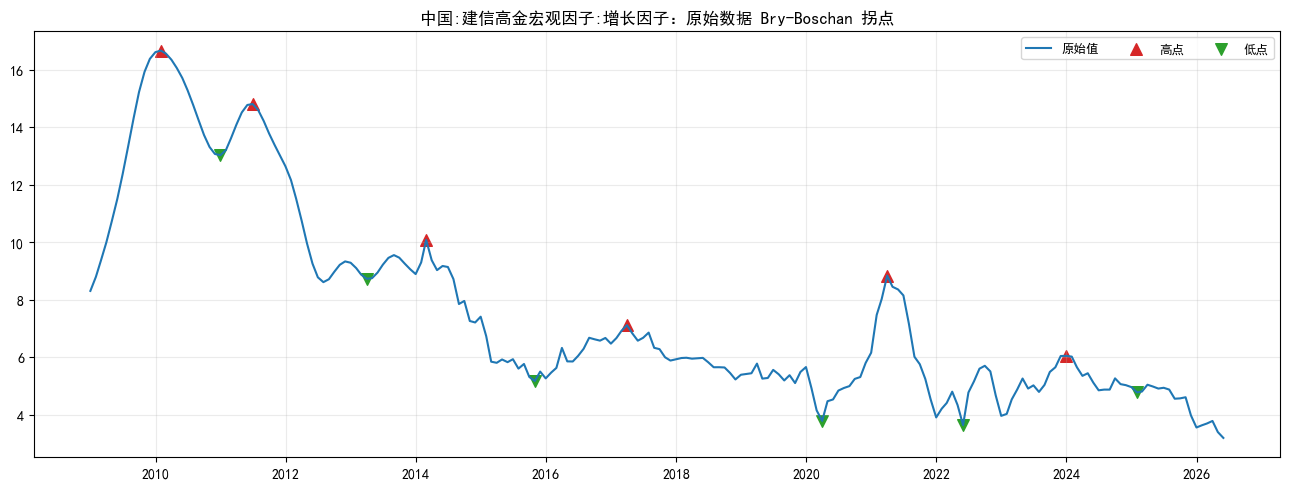

In [30]:
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(13, 5))
peaks = turning_points[turning_points["type"].eq("peak")]
troughs = turning_points[turning_points["type"].eq("trough")]

ax.plot(series.index, series.values, color="#1f77b4", linewidth=1.5, label="原始值")
ax.scatter(peaks["date"], peaks["value"], color="#d62728", marker="^", s=70, label="高点")
ax.scatter(troughs["date"], troughs["value"], color="#2ca02c", marker="v", s=70, label="低点")
ax.set_title(f"{series.name}：原始数据 Bry-Boschan 拐点")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "nanhua_industrial_bb_turns.png", dpi=160)
plt.show()